In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.metrics import mean_absolute_error as mae

df = pd.read_csv('Data - cybercrime_data.csv')

In [4]:
df.head()

,phone,person,id,condition,floors,date,start_time_ascend,end_time_ascend,step_count_ascend,start_time_descend,end_time_descend,step_count_descend,registered_steps_ascend,registered_steps_descend,registered_floors_ascend
0,iphone13m,Mara,1,running,1,27-02-2026,14:01:10,14:01:17,21,14:01:50,14:01:57,23,23,14,1
1,iphone13m,Mara,1,running,1,26-02-2026,14:26:20,14:26:29,22,14:27:45,14:27:52,24,4,10,0
2,iphone13m,Mara,1,running,1,26-02-2026,14:32:35,14:32:43,23,14:33:44,14:33:51,25,21,0,2
3,iphone13m,Mara,1,running,1,27-02-2026,14:06:10,14:06:17,21,14:07:30,14:07:36,23,21,10,1
4,iphone13m,Mara,1,running,1,27-02-2026,14:11:15,14:11:23,20,14:11:55,14:12:01,22,23,8,1


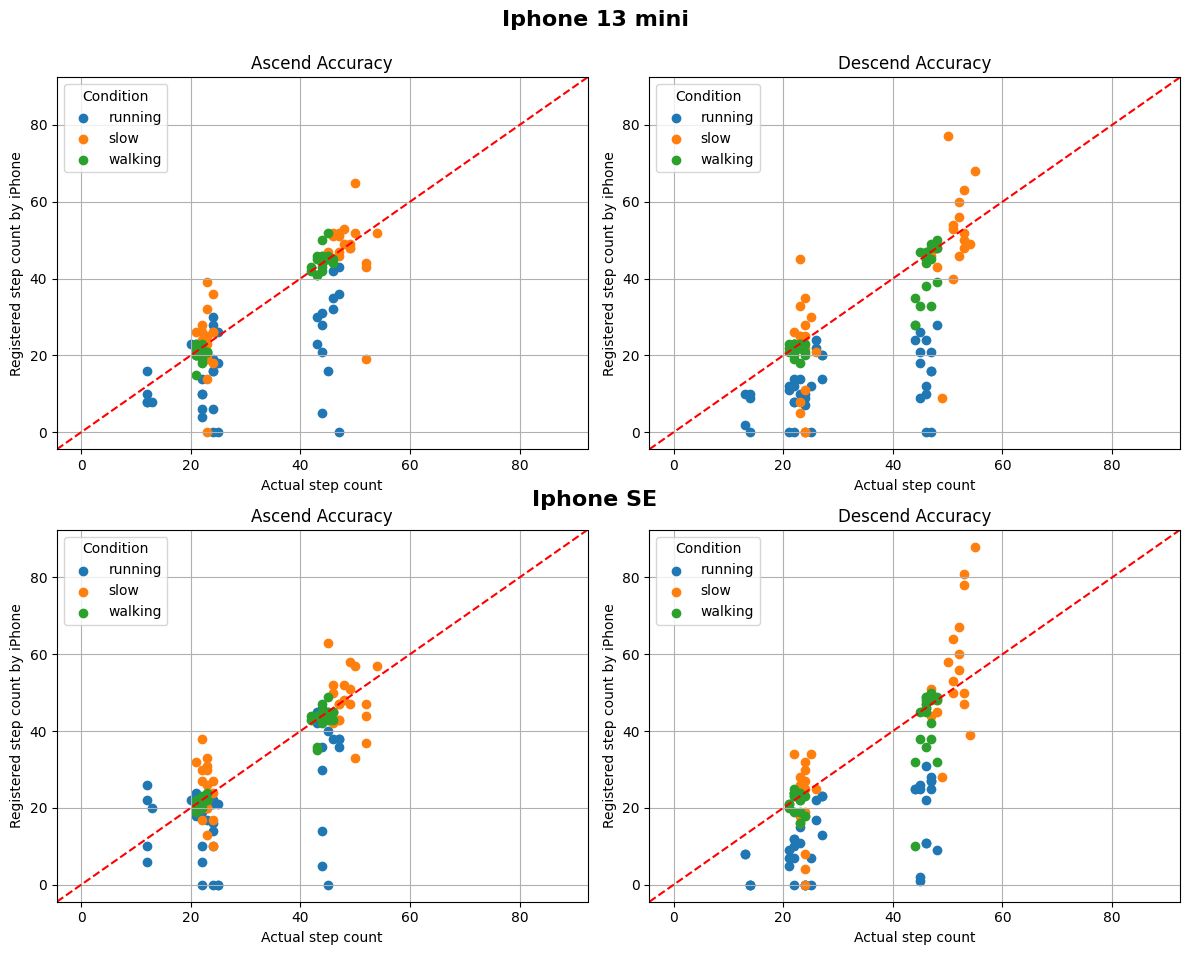

In [23]:
phones = {
    "Iphone 13 mini": df[df['phone'] == 'iphone13m'],
    "Iphone SE": df[df['phone'] == 'iphoneSE']
}

directions = {
    "Ascend": ("step_count_ascend", "registered_steps_ascend"),
    "Descend": ("step_count_descend", "registered_steps_descend")
}

# Create figure with four graphs
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# Global min/max to have fixed axes
all_step_data = pd.concat([
    df[col] for cols in directions.values() for col in cols
])
global_min = all_step_data.min()
global_max = all_step_data.max()

padding = (global_max - global_min) * 0.05
plot_min = global_min - padding
plot_max = global_max + padding

# Plot accuracy per phone, direction and condition
for row, (phone_name, phone_df) in enumerate(phones.items()):

    fig.text(0.5, 0.98 - row*0.48, phone_name,
             ha='center', va='top', fontsize=16, weight='bold')

    for col, (direction, (xcol, ycol)) in enumerate(directions.items()):
        axis = ax[row, col]
        axis.plot([plot_min, plot_max], [plot_min, plot_max], 'r--')

        for condition, subset in phone_df.groupby("condition"):
            axis.scatter(subset[xcol], subset[ycol], label=condition)

        axis.set_title(f"{direction} Accuracy")
        axis.set_xlabel("Actual step count")
        axis.set_ylabel("Registered step count by iPhone")
        axis.set_xlim(plot_min, plot_max)
        axis.set_ylim(plot_min, plot_max)
        axis.grid(True)
        axis.legend(title="Condition")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [6]:
phones = ['iphone13m', 'iphoneSE']
conditions = df['condition'].unique()

mae_results = {}

for phone in phones:
    mae_results[phone] = {}
    for condition in conditions:
        mae_results[phone][condition] = {}

        # Filter data for current phone and condition
        subset = df[(df['phone'] == phone) & (df['condition'] == condition)]

        if not subset.empty:
            # Ascend
            actual_steps_ascend = subset['step_count_ascend']
            registered_steps_ascend = subset['registered_steps_ascend']
            if not actual_steps_ascend.empty and not registered_steps_ascend.empty:
                error_ascend = mae(actual_steps_ascend, registered_steps_ascend)
                mae_results[phone][condition]['ascend'] = error_ascend
            else:
                mae_results[phone][condition]['ascend'] = float('nan')

            # Descend
            actual_steps_descend = subset['step_count_descend']
            registered_steps_descend = subset['registered_steps_descend']
            if not actual_steps_descend.empty and not registered_steps_descend.empty:
                error_descend = mae(actual_steps_descend, registered_steps_descend)
                mae_results[phone][condition]['descend'] = error_descend
            else:
                mae_results[phone][condition]['descend'] = float('nan')
        else:
            mae_results[phone][condition]['ascend'] = float('nan')
            mae_results[phone][condition]['descend'] = float('nan')

# Print the results
for phone, conditions_data in mae_results.items():
    print(f"\n--- {phone.replace('iphone13m', 'iPhone 13 mini').replace('iphoneSE', 'iPhone SE')} ---")
    for condition, directions_data in conditions_data.items():
        print(f"  Condition: {condition.capitalize()}")
        for direction, mae_value in directions_data.items():
            if not pd.isna(mae_value):
                print(f"    MAE ({direction.capitalize()}): {mae_value:.2f}")
            else:
                print(f"    MAE ({direction.capitalize()}): No data")


--- iPhone 13 mini ---
  Condition: Running
    MAE (Ascend): 11.10
    MAE (Descend): 17.98
  Condition: Walking
    MAE (Ascend): 1.75
    MAE (Descend): 2.77
  Condition: Slow
    MAE (Ascend): 5.35
    MAE (Descend): 8.30

--- iPhone SE ---
  Condition: Running
    MAE (Ascend): 10.28
    MAE (Descend): 18.15
  Condition: Walking
    MAE (Ascend): 1.27
    MAE (Descend): 3.77
  Condition: Slow
    MAE (Ascend): 5.80
    MAE (Descend): 8.35


In [7]:
phones = ['iphone13m', 'iphoneSE']
unique_ids = df['id'].unique()

mae_results_by_id = {}

for phone in phones:
    mae_results_by_id[phone] = {}
    for id_val in unique_ids:
        mae_results_by_id[phone][id_val] = {}

        # Filter data for current phone and id
        subset = df[(df['phone'] == phone) & (df['id'] == id_val)]

        if not subset.empty:
            # Ascend
            actual_steps_ascend = subset['step_count_ascend']
            registered_steps_ascend = subset['registered_steps_ascend']
            if not actual_steps_ascend.empty and not registered_steps_ascend.empty:
                error_ascend = mae(actual_steps_ascend, registered_steps_ascend)
                mae_results_by_id[phone][id_val]['ascend'] = error_ascend
            else:
                mae_results_by_id[phone][id_val]['ascend'] = float('nan')

            # Descend
            actual_steps_descend = subset['step_count_descend']
            registered_steps_descend = subset['registered_steps_descend']
            if not actual_steps_descend.empty and not registered_steps_descend.empty:
                error_descend = mae(actual_steps_descend, registered_steps_descend)
                mae_results_by_id[phone][id_val]['descend'] = error_descend
            else:
                mae_results_by_id[phone][id_val]['descend'] = float('nan')
        else:
            mae_results_by_id[phone][id_val]['ascend'] = float('nan')
            mae_results_by_id[phone][id_val]['descend'] = float('nan')

# Print the results
for phone, ids_data in mae_results_by_id.items():
    print(f"\n--- {phone.replace('iphone13m', 'iPhone 13 mini').replace('iphoneSE', 'iPhone SE')} ---")
    for id_val, directions_data in ids_data.items():
        print(f"  Participant ID: {id_val}")
        for direction, mae_value in directions_data.items():
            if not pd.isna(mae_value):
                print(f"    MAE ({direction.capitalize()}): {mae_value:.2f}")
            else:
                print(f"    MAE ({direction.capitalize()}): No data")


--- iPhone 13 mini ---
  Participant ID: 1
    MAE (Ascend): 5.17
    MAE (Descend): 13.80
  Participant ID: 2
    MAE (Ascend): 3.13
    MAE (Descend): 4.97
  Participant ID: 3
    MAE (Ascend): 5.20
    MAE (Descend): 8.13
  Participant ID: 4
    MAE (Ascend): 10.77
    MAE (Descend): 11.83

--- iPhone SE ---
  Participant ID: 1
    MAE (Ascend): 3.53
    MAE (Descend): 11.53
  Participant ID: 2
    MAE (Ascend): 3.83
    MAE (Descend): 7.07
  Participant ID: 3
    MAE (Ascend): 5.83
    MAE (Descend): 10.33
  Participant ID: 4
    MAE (Ascend): 9.93
    MAE (Descend): 11.43


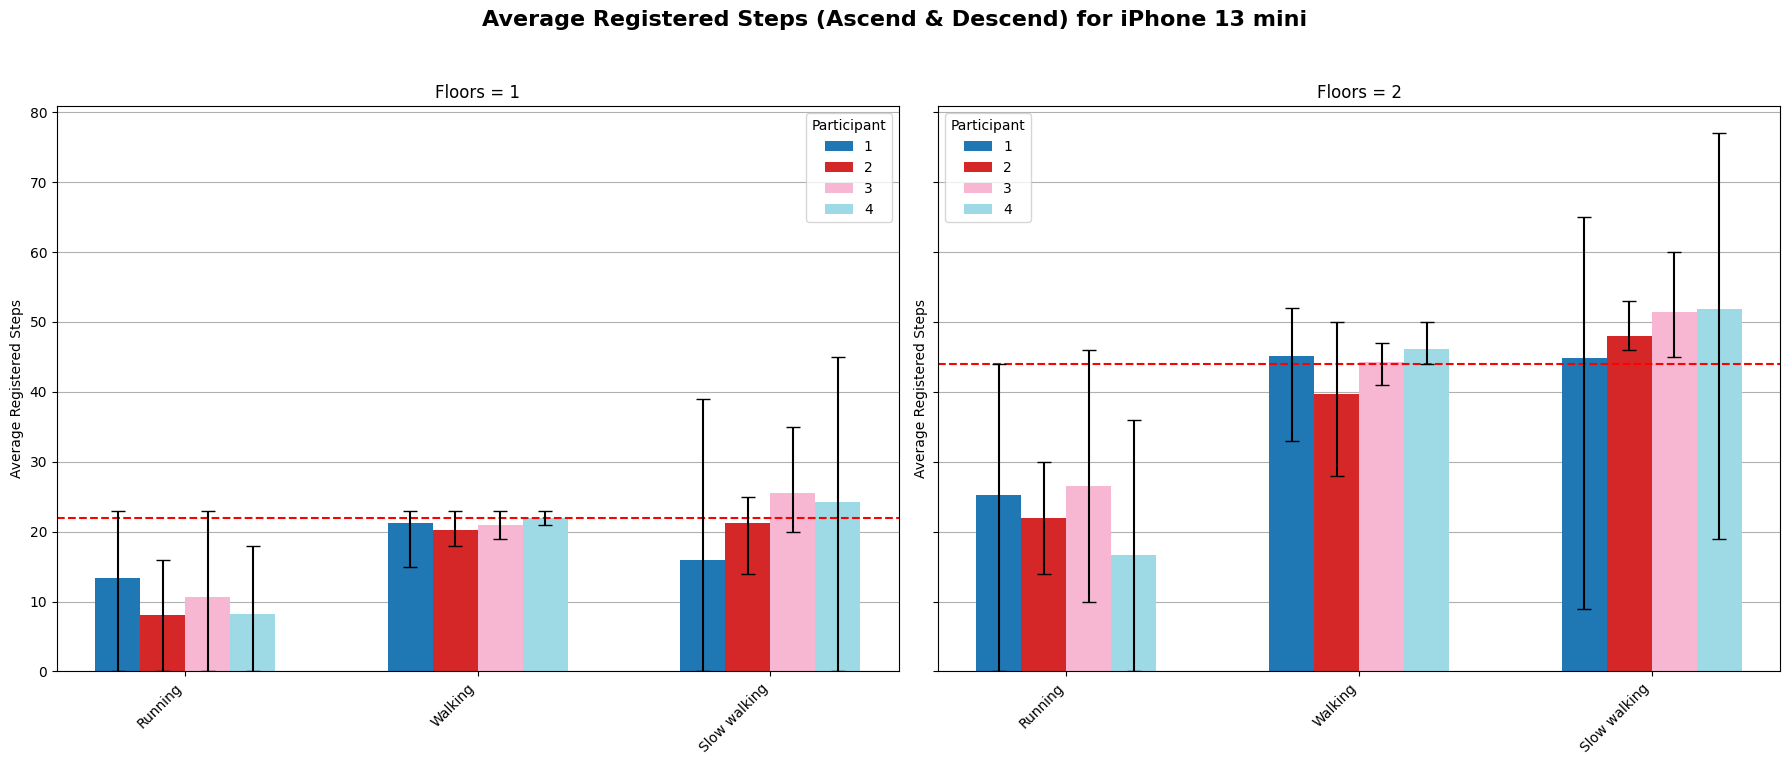

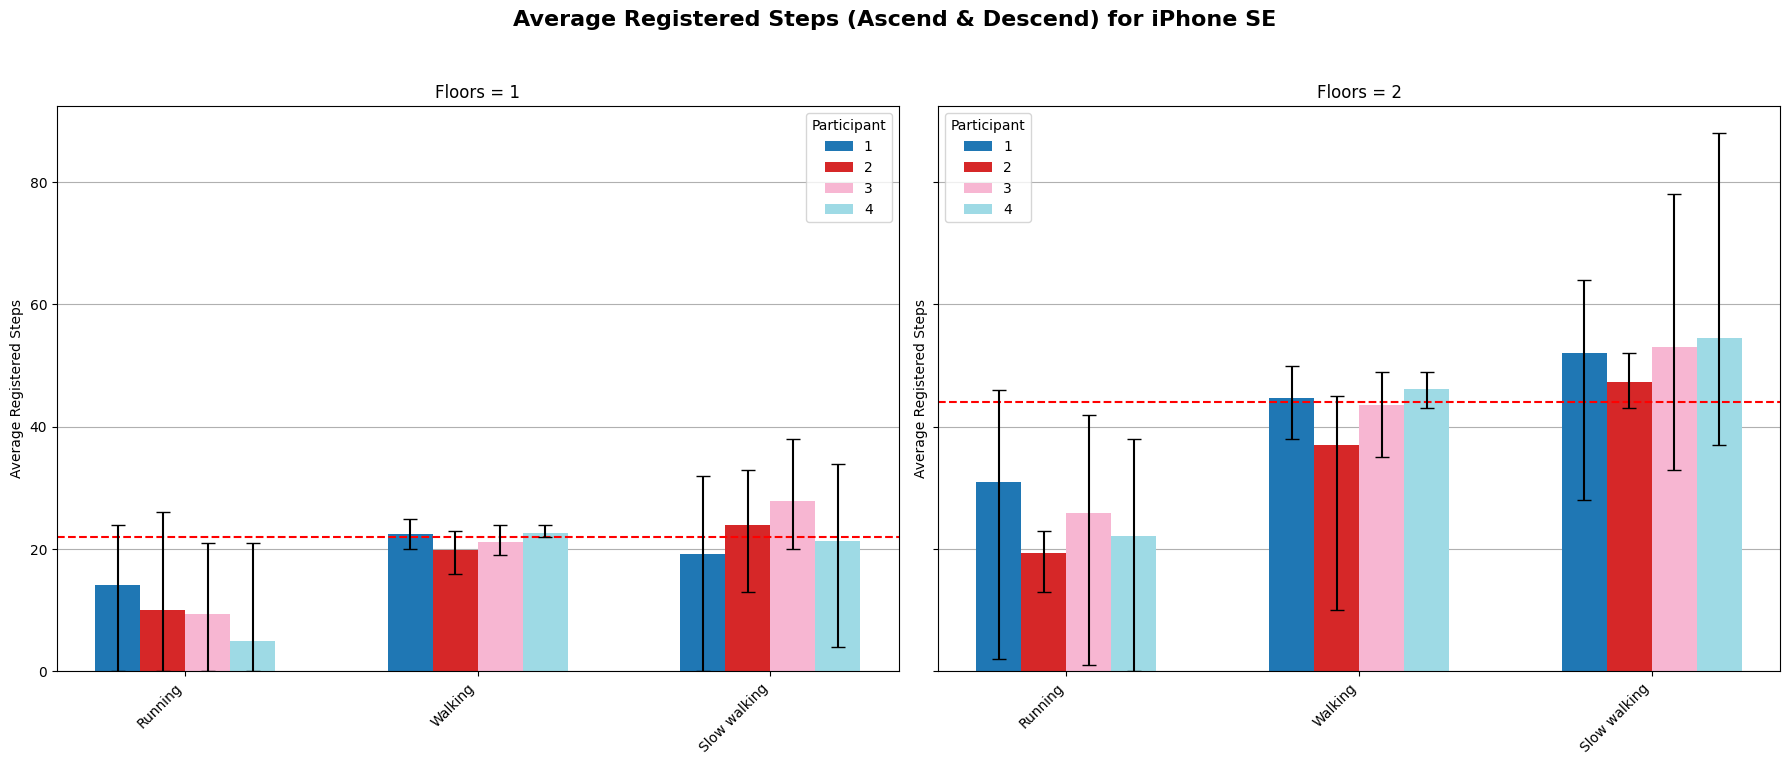

In [78]:
# Define phone names for display
phones_map = {
    "iphone13m": "iPhone 13 mini",
    "iphoneSE": "iPhone SE"
}

unique_conditions = df['condition'].unique()
unique_ids = df['id'].unique() # Change to unique IDs
num_ids = len(unique_ids) # Number of unique IDs
num_conditions = len(unique_conditions)

# Loop through each phone to create a separate figure
for phone_id, phone_name_display in phones_map.items():
    phone_df = df[df['phone'] == phone_id]

    # Create a figure with two subplots (one for floors = 1, one for floors = 2)
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
    fig.suptitle(f'Average Registered Steps (Ascend & Descend) for {phone_name_display}', fontsize=16, weight='bold') # Title updated to reflect steps

    # Iterate through unique floor values (1 and 2)
    for col_idx, floor_val in enumerate([1, 2]):
        current_ax = axes[col_idx]
        current_ax.set_axisbelow(True) # Ensure grid is below bars

        # Filter data for the current floor value
        floor_specific_df = phone_df[phone_df['floors'] == floor_val]

        # Prepare data for grouped bars: X-axis by condition, grouped by ID
        means_per_condition_id = {} # {condition: {id: mean_val}}
        mins_per_condition_id = {}  # {condition: {id: min_val}} for error bars
        maxs_per_condition_id = {}  # {condition: {id: max_val}} for error bars

        for condition in unique_conditions:
            means_per_condition_id[condition] = {}
            mins_per_condition_id[condition] = {}
            maxs_per_condition_id[condition] = {}
            for id_val in unique_ids:
                subset = floor_specific_df[
                    (floor_specific_df['id'] == id_val) &
                    (floor_specific_df['condition'] == condition)
                ]

                if not subset.empty:
                    # Combine registered steps for ascend and descend
                    combined_registered_steps = pd.concat([
                        subset['registered_steps_ascend'],
                        subset['registered_steps_descend']
                    ]).dropna() # Drop NaN values if any exist from one of the columns

                    if not combined_registered_steps.empty:
                        means_per_condition_id[condition][id_val] = combined_registered_steps.mean()
                        mins_per_condition_id[condition][id_val] = combined_registered_steps.min()
                        maxs_per_condition_id[condition][id_val] = combined_registered_steps.max()
                    else:
                        means_per_condition_id[condition][id_val] = np.nan
                        mins_per_condition_id[condition][id_val] = np.nan
                        maxs_per_condition_id[condition][id_val] = np.nan
                else:
                    means_per_condition_id[condition][id_val] = np.nan
                    mins_per_condition_id[condition][id_val] = np.nan
                    maxs_per_condition_id[condition][id_val] = np.nan

        # Plotting grouped bars
        bar_width = 0.2 # Smaller bar width for 4 groups
        id_colors = plt.colormaps['tab20'](np.linspace(0, 1, num_ids)) # Get unique colors for each ID

        # Base x-positions for each condition group
        x_base = np.arange(num_conditions) * (num_ids * bar_width + 0.5) # +0.5 for spacing between condition groups

        for i, id_val in enumerate(unique_ids):
            means = [means_per_condition_id[cond][id_val] for cond in unique_conditions]
            mins = [mins_per_condition_id[cond][id_val] for cond in unique_conditions]
            maxs = [maxs_per_condition_id[cond][id_val] for cond in unique_conditions]

            # Calculate error bars (distance from mean to min, and from mean to max)
            lower_errors = [mean_val - min_val if not pd.isna(mean_val) and not pd.isna(min_val) else np.nan for mean_val, min_val in zip(means, mins)]
            upper_errors = [max_val - mean_val if not pd.isna(mean_val) and not pd.isna(max_val) else np.nan for mean_val, max_val in zip(means, maxs)]
            yerr_values = np.array([lower_errors, upper_errors])

            # Offset each ID's bars within the condition group
            x_offset = x_base + i * bar_width

            current_ax.bar(x_offset, means, yerr=yerr_values, width=bar_width, capsize=5, label=f'{id_val}', color=id_colors[i])

        current_ax.set_ylabel('Average Registered Steps')
        current_ax.set_title(f'Floors = {floor_val}')
        current_ax.set_xticks(x_base + (num_ids - 1) * bar_width / 2)
        current_ax.set_xticklabels(['Running', 'Walking', 'Slow walking'], rotation=45, ha='right')
        current_ax.grid(True)
        current_ax.legend(title='Participant')
        current_ax.grid(axis='x')


        # Add horizontal line at expected values
        if floor_val == 1:
            current_ax.axhline(y=22, color='red', linestyle='--', zorder=1)
        elif floor_val == 2:
            current_ax.axhline(y=44, color='red', linestyle='--', zorder=1)
        current_ax.legend(title='Participant')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

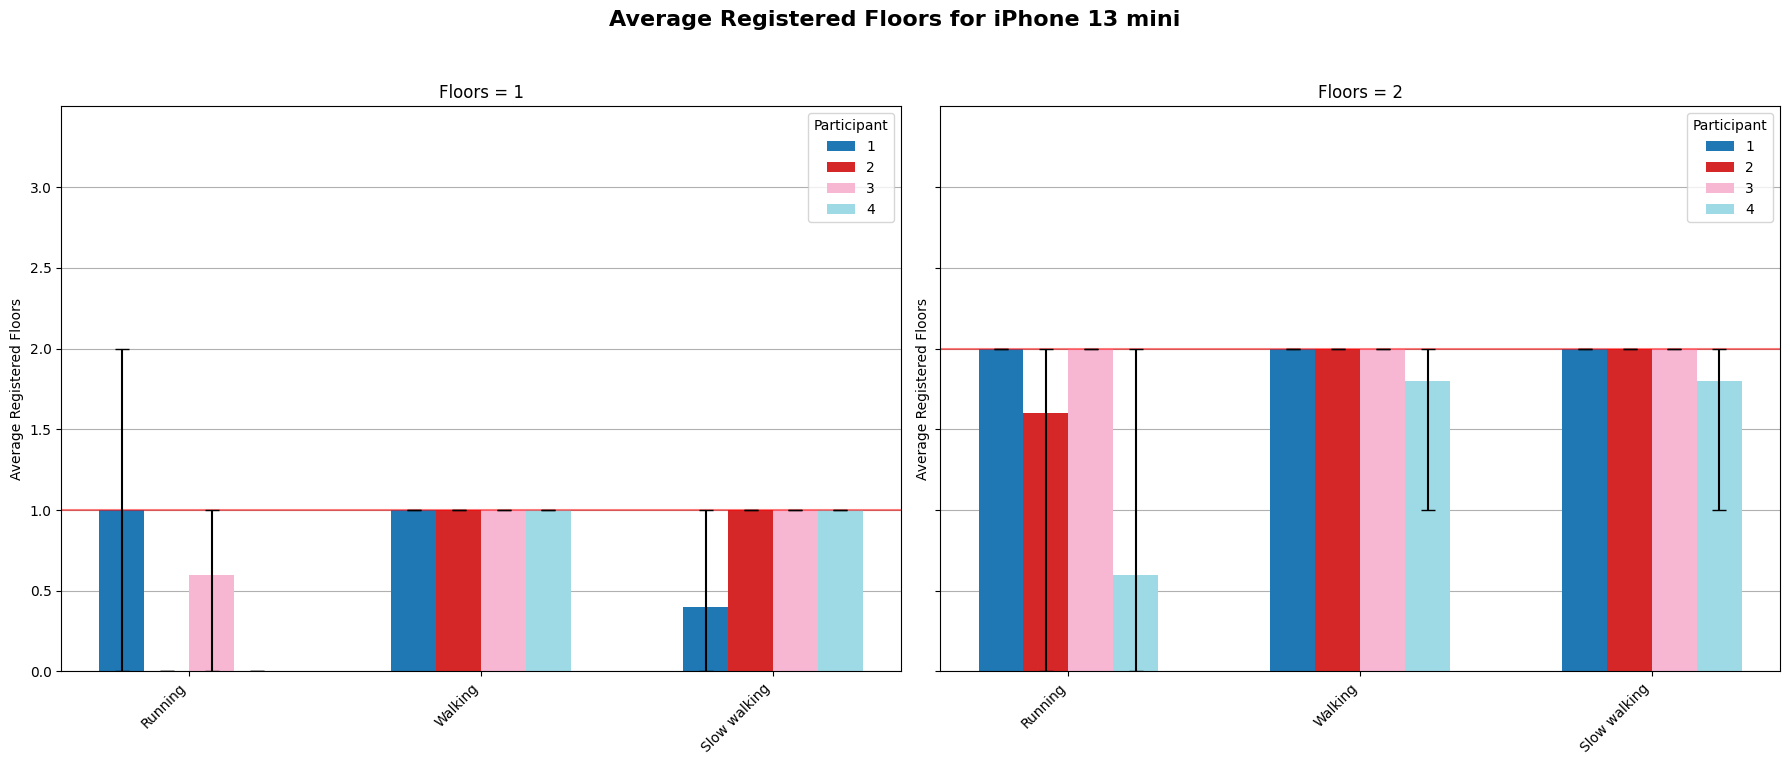

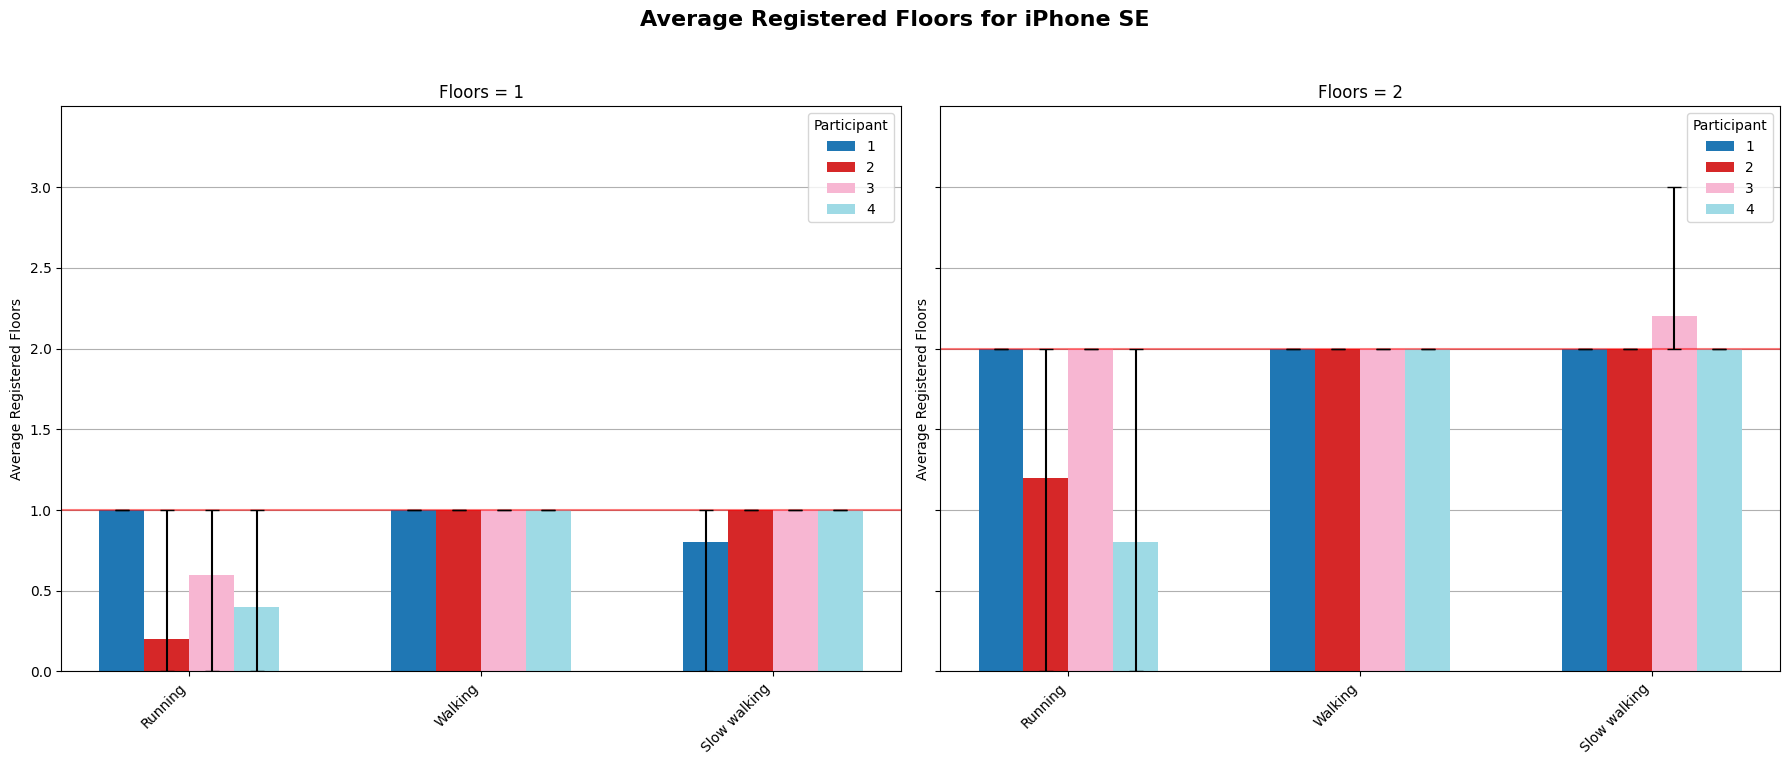

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define phone names for display
phones_map = {
    "iphone13m": "iPhone 13 mini",
    "iphoneSE": "iPhone SE"
}

unique_conditions = df['condition'].unique()
unique_ids = df['id'].unique() # Change to unique IDs
num_ids = len(unique_ids) # Number of unique IDs
num_conditions = len(unique_conditions)

# Loop through each phone to create a separate figure
for phone_id, phone_name_display in phones_map.items():
    phone_df = df[df['phone'] == phone_id]

    # Create a figure with two subplots (one for floors = 1, one for floors = 2)
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
    fig.suptitle(f'Average Registered Floors for {phone_name_display}', fontsize=16, weight='bold')

    # Iterate through unique floor values (1 and 2)
    for col_idx, floor_val in enumerate([1, 2]):
        current_ax = axes[col_idx]
        current_ax.set_axisbelow(True) # Ensure grid is below bars

        # Filter data for the current floor value
        floor_specific_df = phone_df[phone_df['floors'] == floor_val]

        # Prepare data for grouped bars: X-axis by condition, grouped by ID
        means_per_condition_id = {} # {condition: {id: mean_val}}
        mins_per_condition_id = {}  # {condition: {id: min_val}} for error bars
        maxs_per_condition_id = {}  # {condition: {id: max_val}} for error bars

        for condition in unique_conditions:
            means_per_condition_id[condition] = {}
            mins_per_condition_id[condition] = {}
            maxs_per_condition_id[condition] = {}
            for id_val in unique_ids:
                subset = floor_specific_df[
                    (floor_specific_df['id'] == id_val) &
                    (floor_specific_df['condition'] == condition)
                ]

                if not subset.empty:
                    # Use registered_floors_ascend directly
                    registered_floors_data = subset['registered_floors_ascend'].dropna()

                    if not registered_floors_data.empty:
                        means_per_condition_id[condition][id_val] = registered_floors_data.mean()
                        mins_per_condition_id[condition][id_val] = registered_floors_data.min()
                        maxs_per_condition_id[condition][id_val] = registered_floors_data.max()
                    else:
                        means_per_condition_id[condition][id_val] = np.nan
                        mins_per_condition_id[condition][id_val] = np.nan
                        maxs_per_condition_id[condition][id_val] = np.nan
                else:
                    means_per_condition_id[condition][id_val] = np.nan
                    mins_per_condition_id[condition][id_val] = np.nan
                    maxs_per_condition_id[condition][id_val] = np.nan

        # Plotting grouped bars
        bar_width = 0.2 # Smaller bar width for 4 groups
        id_colors = plt.colormaps['tab20'](np.linspace(0, 1, num_ids)) # Get unique colors for each ID

        # Base x-positions for each condition group
        x_base = np.arange(num_conditions) * (num_ids * bar_width + 0.5) # +0.5 for spacing between condition groups

        for i, id_val in enumerate(unique_ids):
            means = [means_per_condition_id[cond][id_val] for cond in unique_conditions]
            mins = [mins_per_condition_id[cond][id_val] for cond in unique_conditions]
            maxs = [maxs_per_condition_id[cond][id_val] for cond in unique_conditions]

            # Calculate asymmetric error bars (distance from mean to min, and from mean to max)
            minimum = [mean_val - min_val if not pd.isna(mean_val) and not pd.isna(min_val) else np.nan for mean_val, min_val in zip(means, mins)]
            maximum = [max_val - mean_val if not pd.isna(mean_val) and not pd.isna(max_val) else np.nan for mean_val, max_val in zip(means, maxs)]
            yminmax_values = np.array([minimum, maximum])

            # Offset each ID's bars within the condition group
            x_offset = x_base + i * bar_width

            current_ax.bar(x_offset, means, yerr=yminmax_values, width=bar_width, capsize=5, label=f'{id_val}', color=id_colors[i])

        current_ax.set_ylabel('Average Registered Floors') # Label updated
        current_ax.set_title(f'Floors = {floor_val}') # Title based on floor value
        current_ax.set_xticks(x_base + (num_ids - 1) * bar_width / 2) # Center xticks under the group of bars
        current_ax.set_xticklabels(['Running', 'Walking', 'Slow walking'], rotation=45, ha='right')
        current_ax.grid(True) # Keep grid for both axes
        current_ax.legend(title='Participant')
        current_ax.grid(axis='x')

        # Set y-axis limits and ticks
        current_ax.set_ylim(0, 3.5) # Set y-axis limit from 0 to 3
        current_ax.set_yticks(np.arange(0, 3.5, 0.5)) # Set y-axis ticks in steps of 0.5

        # Add horizontal lines with zorder to place them behind bars
        if floor_val == 1:
            current_ax.axhline(y=1, color='red', linestyle='-', zorder=1, alpha=0.5) # Target is 1 floor, added alpha
        elif floor_val == 2:
            current_ax.axhline(y=2, color='red', linestyle='-', zorder=1, alpha=0.5) # Target is 2 floors, added alpha
        current_ax.legend(title='Participant') # Update legend to include the new line

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()